# Задача 3. Реализация обхода в ширину из нескольких стартовых вершин (Multiple-Source BFS)

In [5]:
import graphblas as gb
from graphblas import Matrix
from collections import deque

import time
import random
import statistics
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import os
import tarfile
import urllib.request

from scipy.io import mmread

Зададим вспомогательные функции, которые понадобятся в дальнейшем

In [6]:
# Ф-я построения матрицы смежности
def build_adjacency_matrix(n, edges):
    rows = [u for u, v in edges]
    cols = [v for u, v in edges]
    vals = [True] * len(edges)

    return Matrix.from_coo(
        rows,
        cols,
        vals,
        nrows=n,
        ncols=n,
        dtype=gb.dtypes.BOOL,
    )

# Ф-я булевого матричного умножения
def boolean_mxm(left, right):
    try:
        result = left.mxm(right, op="lor_land")
        return result.new() if hasattr(result, "new") else result
    except Exception:
        pass

# Визуализация графа (ориентированный): n, edges, sources из ячейки выше
def draw_graph(n, edges, sources=None):
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Размещение вершин по кругу
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    pos = {i: (np.cos(angles[i]), np.sin(angles[i])) for i in range(n)}
    
    # Рёбра
    for u, v in edges:
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        dx, dy = x2 - x1, y2 - y1
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", color="gray", lw=1.5),
                    xycoords="data", textcoords="data")
    
    # Вершины
    source_set = set(sources or [])
    for i in range(n):
        x, y = pos[i]
        color = "tab:green" if i in source_set else "lightblue"
        circle = plt.Circle((x, y), 0.12, color=color, ec="black", zorder=2)
        ax.add_patch(circle)
        ax.text(x, y, str(i), ha="center", va="center", fontsize=12, zorder=3)
    ax.set_xlim(-1.4, 1.4)
    ax.set_ylim(-1.4, 1.4)
    ax.set_aspect("equal")
    ax.axis("off")
    if sources:
        ax.set_title(f"Граф (n={n})")
    plt.tight_layout()
    plt.show()

### Задание 1

Используя python-graphblas реализовать функцию обхода ориентированного графа (MSBFS-Levels) в ширину из нескольких заданных стартовых вершин.

- Функция принимает представление графа, удобное для неё (загрузка, конвертация реализованы отдельно) и массив номеров стартовых вершин.
- Функция возвращает массив пар: стартовая вершина, и массив (levels), где для каждой вершины указано, на каком уровне она достижима из этой стартовой. Стартовая вершина достижима на нулевом уровне, если вершина не достижима, то значение соответствующей ячейки сделайте равной -1.

#### Решение

**MSBFS (Multi-Source Breadth-First Search)** — это обобщение классического обхода графа в ширину (BFS) сразу для нескольких стартовых вершин.


Обычный BFS запускается из одной вершины и находит кратчайшие расстояния до всех достижимых вершин.  

MSBFS делает то же самое, но запускает BFS для каждой стартовой вершины отдельно,  


Алгоритм основан на идее послойного обхода графа:

1. **Начальный шаг (уровень 0):**  
   Стартовая вершина имеет уровень `0`.

2. **Первый уровень:**  
   Все вершины, в которые можно попасть напрямую, получают уровень `1`.

3. **Дальнейшие уровни:**  
   На каждом шаге рассматриваются вершины, достигнутые на предыдущем уровне, и находятся их соседи, которые ещё не посещались.

4. **Остановка:**  
   Алгоритм завершается, когда новых вершин больше нет.

5. **Недостижимые вершины:**  
   Если до вершины нельзя добраться из стартовой, её уровень остаётся `-1`.


На каждом шаге поддерживается множество вершин, называемое **фронтом**:

- `front` — вершины текущего уровня  
- `next_front` — вершины следующего уровня  

При этом:
- уже посещённые вершины исключаются
- новым вершинам присваивается текущий уровень


In [19]:
# обход в ширину из нескольких стартовых вершин
# Для каждого источника возвращает массив уровней: levels[v] = номер шага достижимости (0 — сама вершина, -1 — недостижима).
def msbfs_levels(A, sources):

    n = A.nrows
    
    for s in sources:
        if not (0 <= s < n):
            raise ValueError(f"Стартовая вершина {s} вне диапазона [0, {n - 1}]")
    
    m = len(sources)

    # Начальный frontier: в i-й строке отмечена только вершина sources[i]
    frontier = Matrix.from_coo(
      list(range(m)),
      list(sources),
      [True] * m,
      nrows=m,
      ncols=n,
      dtype=gb.dtypes.BOOL,
)

    # levels[i][v] = уровень вершины v для источника sources[i]
    levels = [[-1] * n for _ in range(m)]
    for i, s in enumerate(sources):
        levels[i][s] = 0

    current_level = 1

    while frontier.nvals > 0:
        next_frontier = boolean_mxm(frontier, A)

        rows, cols, vals = next_frontier.to_coo()

        new_rows = []
        new_cols = []
        new_vals = []

        for i, v in zip(rows, cols):
            if levels[i][v] == -1:
                levels[i][v] = current_level
                new_rows.append(i)
                new_cols.append(v)
                new_vals.append(True)

        if not new_rows:
            break

        frontier = Matrix.from_coo(
            new_rows,
            new_cols,
            new_vals,
            nrows=m,
            ncols=n,
            dtype=gb.dtypes.BOOL,
        )

        current_level += 1

    return [(sources[i], levels[i]) for i in range(m)]

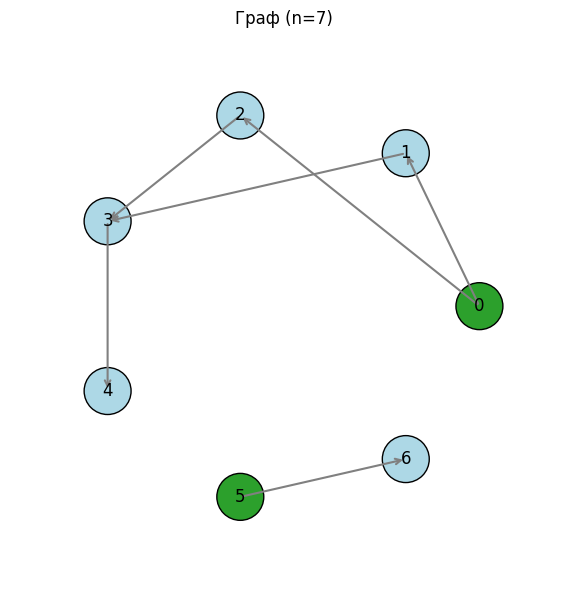

Result: [(0, [0, 1, 1, 2, 3, -1, -1]), (5, [-1, -1, -1, -1, -1, 0, 1])]


In [20]:
n = 7
edges = [
    (0, 1),
    (0, 2),
    (1, 3),
    (2, 3),
    (3, 4),
    (5, 6),
]

A = build_adjacency_matrix(n, edges)
sources = [0, 5]

result = msbfs_levels(A, sources)
draw_graph(n, edges, sources)
print('Result:', result)

#### Тесты

In [21]:
# обычный BFS из одной вершины для тестов
def bfs_levels_python(n, edges, source):
    graph = [[] for _ in range(n)]
    for u, v in edges:
        graph[u].append(v)

    levels = [-1] * n
    levels[source] = 0

    q = deque([source])

    while q:
        u = q.popleft()
        for v in graph[u]:
            if levels[v] == -1:
                levels[v] = levels[u] + 1
                q.append(v)

    return levels


# запускаем все тесты
def run_all_tests():
    total = 7
    passed = 0

    try:
        # Тест 1: простой граф
        n = 7
        edges = [(0, 1), (0, 2), (1, 3), (2, 3), (3, 4), (5, 6)]
        A = build_adjacency_matrix(n, edges)
        result = dict(msbfs_levels(A, [0, 5]))
        assert result[0] == [0, 1, 1, 2, 3, -1, -1], "Тест 1: ошибка для source=0"
        assert result[5] == [-1, -1, -1, -1, -1, 0, 1], "Тест 1: ошибка для source=5"
        passed += 1

        # Тест 2: граф с циклом
        n = 4
        edges = [(0, 1), (1, 2), (2, 0), (2, 3)]
        A = build_adjacency_matrix(n, edges)
        result = dict(msbfs_levels(A, [0]))
        assert result[0] == [0, 1, 2, 3], "Тест 2: ошибка на графе с циклом"
        passed += 1

        # Тест 3: недостижимые вершины
        n = 5
        edges = [(0, 1), (1, 2)]
        A = build_adjacency_matrix(n, edges)
        result = dict(msbfs_levels(A, [0, 3]))
        assert result[0] == [0, 1, 2, -1, -1], "Тест 3: ошибка для source=0"
        assert result[3] == [-1, -1, -1, 0, -1], "Тест 3: ошибка для source=3"
        passed += 1

        # Тест 4: несколько источников
        n = 6
        edges = [(0, 1), (1, 2), (2, 3), (4, 5)]
        A = build_adjacency_matrix(n, edges)
        result = dict(msbfs_levels(A, [0, 4]))
        assert result[0] == [0, 1, 2, 3, -1, -1], "Тест 4: ошибка для source=0"
        assert result[4] == [-1, -1, -1, -1, 0, 1], "Тест 4: ошибка для source=4"
        passed += 1

        # Тест 5: пустой список источников
        n = 3
        edges = [(0, 1), (1, 2)]
        A = build_adjacency_matrix(n, edges)
        result = msbfs_levels(A, [])
        assert result == [], "Тест 5: для пустого списка должен возвращаться пустой список"
        passed += 1

        # Тест 6: некорректный источник
        n = 3
        edges = [(0, 1)]
        A = build_adjacency_matrix(n, edges)
        try:
            msbfs_levels(A, [3])
            raise AssertionError("Тест 6: ожидалось исключение ValueError")
        except ValueError:
            pass
        passed += 1

        # Тест 7: сравнение с обычным BFS
        n = 7
        edges = [(0, 1), (0, 2), (1, 3), (2, 3), (3, 4), (5, 6)]
        A = build_adjacency_matrix(n, edges)
        sources = [0, 5]
        result = dict(msbfs_levels(A, sources))
        for s in sources:
            expected = bfs_levels_python(n, edges, s)
            assert result[s] == expected, f"Тест 7: несовпадение с обычным BFS для source={s}"
        passed += 1

        print(f"Все тесты пройдены: {passed}/{total}")

    except AssertionError as e:
        print(f"Тест провален: {e}")
    except Exception as e:
        print(f"Ошибка выполнения: {type(e).__name__}: {e}")


run_all_tests()

Все тесты пройдены: 7/7


### Задание 2

Используя python-graphblas реализовать функцию обхода ориентированного графа (MSBFS-Parents) в ширину из нескольких заданных стартовых вершин.

- Функция принимает представление графа, удобное для неё (загрузка, конвертация реализованы отдельно) и массив номеров стартовых вершин.
- Функция возвращает массив пар: стартовая вершина, и массив (parents), где для каждой вершины графа указано, из какой вершины мы пришли в эту по кратчайшему пути из стартовой вершины. При этом для самой стартовой вершины такое значение взять равное -1, а для недостижимых вершин взять равное -2. При наличии нескольких возможных значений в массивах parents брать наименьшее.

#### Решение

Если в предыдущем задании (MSBFS-Levels) мы находили расстояния, то здесь мы восстанавливаем **структуру дерева поиска**.

Для каждой вершины сохраняется из какой вершины мы в неё пришли впервые. Это и есть её parent

Таким образом, результат — это **BFS-дерево** для каждой стартовой вершины.

Алгоритм остаётся послойным, но добавляется отслеживание родителей.

1. **Инициализация:**
   - `parents[v] = -2` для всех вершин (ещё не достигнуты)
   - для стартовой вершины: `parents[s] = -1`

2. **Фронт (front):**
   - содержит вершины текущего уровня

3. **Переход на следующий уровень:**
   - находим всех соседей текущего фронта
   - исключаем уже посещённые вершины
   - для каждой новой вершины фиксируем из какой вершины мы в неё пришли

4. **Выбор родителя:**
   - если в вершину можно прийти из нескольких вершин на одном уровне  
     → выбирается вершина с минимальным номером


**Ключевая идея отличия от Levels**

В MSBFS-Levels важно **когда** вершина достигнута.  
В MSBFS-Parents важно **откуда** она достигнута.

In [27]:
# BFS из нескольких стартовых вершин с восстановлением предков. 
# Для каждого источника возвращает parents: parents[v] = предок v на кратчайшем пути
def msbfs_parents(A, sources):

    n = A.nrows
    
    for s in sources:
        if not (0 <= s < n):
            raise ValueError(f"Стартовая вершина {s} вне диапазона [0, {n - 1}]")
    
    m = len(sources)

    adj = [[] for _ in range(n)]
    rows, cols, _ = A.to_coo()
    for u, v in zip(rows, cols):
        adj[u].append(v)

    # Начальный frontier: в i-й строке отмечена только вершина sources[i]
    frontier = Matrix.from_coo(
        list(range(m)),
        list(sources),
        [True] * m,
        nrows=m,
        ncols=n,
        dtype=gb.dtypes.BOOL,
    )

    parents = [[-2] * n for _ in range(m)]
    for i, s in enumerate(sources):
        parents[i][s] = -1

    while frontier.nvals > 0:
        next_frontier = boolean_mxm(frontier, A)

        f_rows, f_cols, _ = frontier.to_coo()

        current_by_source = [[] for _ in range(m)]
        for i, u in zip(f_rows, f_cols):
            current_by_source[i].append(u)

        next_rows = []
        next_cols = []
        next_vals = []

        for i in range(m):
            candidate_parent = {}

            for u in current_by_source[i]:
                for v in adj[u]:
                    if parents[i][v] == -2:
                        if v not in candidate_parent or u < candidate_parent[v]:
                            candidate_parent[v] = u

            for v in sorted(candidate_parent.keys()):
                parents[i][v] = int(candidate_parent[v])
                next_rows.append(i)
                next_cols.append(v)
                next_vals.append(True)

        if not next_rows:
            break

        frontier = Matrix.from_coo(
            next_rows,
            next_cols,
            next_vals,
            nrows=m,
            ncols=n,
            dtype=gb.dtypes.BOOL,
        )

    return [(sources[i], parents[i]) for i in range(m)]

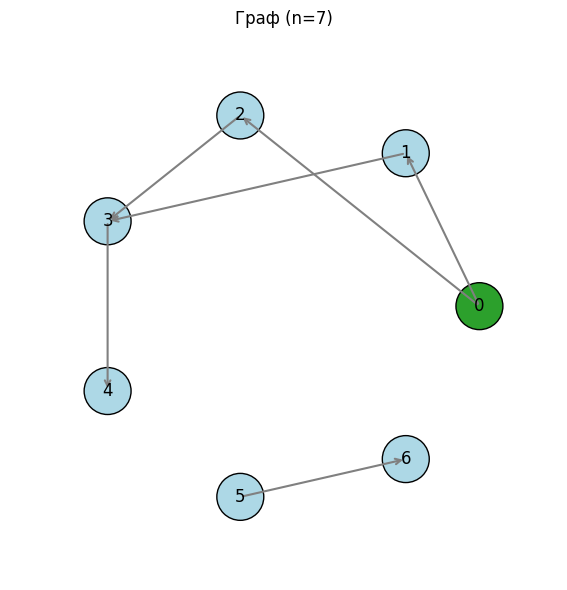

Result: [(0, [-1, 0, 0, 1, 3, -2, -2])]


In [29]:
n = 7
edges = [
    (0, 1),
    (0, 2),
    (1, 3),
    (2, 3),
    (3, 4),
    (5, 6),
]

A = build_adjacency_matrix(n, edges)
result = msbfs_parents(A, sources)
result
draw_graph(n, edges, sources)
print('Result:', result)

#### Тесты

In [30]:
# bfs_parents_python: обычный BFS из одной вершины с массивом предков. Используется в тестах.
def bfs_parents_python(n, edges, source):
    graph = [[] for _ in range(n)]
    for u, v in edges:
        graph[u].append(v)

    parents = [-2] * n
    dist = [-1] * n

    parents[source] = -1
    dist[source] = 0

    q = deque([source])

    while q:
        u = q.popleft()
        for v in graph[u]:
            if dist[v] == -1:
                dist[v] = dist[u] + 1
                parents[v] = u
                q.append(v)
            elif dist[v] == dist[u] + 1:
                parents[v] = min(parents[v], u)

    return parents


# run_all_parents_tests: проверки для msbfs_parents (корректность и сравнение с BFS).
def run_all_parents_tests():
    total = 8
    passed = 0

    try:
        # Тест 1: простой граф
        n = 7
        edges = [(0, 1), (0, 2), (1, 3), (2, 3), (3, 4), (5, 6)]
        A = build_adjacency_matrix(n, edges)
        result = dict(msbfs_parents(A, [0, 5]))
        assert result[0] == [-1, 0, 0, 1, 3, -2, -2], "Тест 1: ошибка для source=0"
        assert result[5] == [-2, -2, -2, -2, -2, -1, 5], "Тест 1: ошибка для source=5"
        passed += 1

        # Тест 2: граф с циклом
        n = 4
        edges = [(0, 1), (1, 2), (2, 0), (2, 3)]
        A = build_adjacency_matrix(n, edges)
        result = dict(msbfs_parents(A, [0]))
        assert result[0] == [-1, 0, 1, 2], "Тест 2: ошибка на графе с циклом"
        passed += 1

        # Тест 3: недостижимые вершины
        n = 5
        edges = [(0, 1), (1, 2)]
        A = build_adjacency_matrix(n, edges)
        result = dict(msbfs_parents(A, [0, 3]))
        assert result[0] == [-1, 0, 1, -2, -2], "Тест 3: ошибка для source=0"
        assert result[3] == [-2, -2, -2, -1, -2], "Тест 3: ошибка для source=3"
        passed += 1

        # Тест 4: несколько источников
        n = 6
        edges = [(0, 1), (1, 2), (2, 3), (4, 5)]
        A = build_adjacency_matrix(n, edges)
        result = dict(msbfs_parents(A, [0, 4]))
        assert result[0] == [-1, 0, 1, 2, -2, -2], "Тест 4: ошибка для source=0"
        assert result[4] == [-2, -2, -2, -2, -1, 4], "Тест 4: ошибка для source=4"
        passed += 1

        # Тест 5: выбор минимального родителя
        n = 5
        edges = [(0, 1), (0, 2), (1, 3), (2, 3), (1, 4), (2, 4)]
        A = build_adjacency_matrix(n, edges)
        result = dict(msbfs_parents(A, [0]))
        assert result[0] == [-1, 0, 0, 1, 1], "Тест 5: должен выбираться минимальный родитель"
        passed += 1

        # Тест 6: пустой список источников
        n = 3
        edges = [(0, 1), (1, 2)]
        A = build_adjacency_matrix(n, edges)
        result = msbfs_parents(A, [])
        assert result == [], "Тест 6: для пустого списка должен возвращаться пустой список"
        passed += 1

        # Тест 7: некорректная стартовая вершина
        n = 3
        edges = [(0, 1)]
        A = build_adjacency_matrix(n, edges)
        try:
            msbfs_parents(A, [3])
            raise AssertionError("Тест 7: ожидалось исключение ValueError")
        except ValueError:
            pass
        passed += 1

        # Тест 8: сравнение с обычным BFS
        n = 7
        edges = [(0, 1), (0, 2), (1, 3), (2, 3), (3, 4), (5, 6)]
        A = build_adjacency_matrix(n, edges)
        sources = [0, 5]
        result = dict(msbfs_parents(A, sources))
        for s in sources:
            expected = bfs_parents_python(n, edges, s)
            assert result[s] == expected, f"Тест 8: несовпадение с обычным BFS для source={s}"
        passed += 1

        print(f"Все тесты пройдены: {passed}/{total}")

    except AssertionError as e:
        print(f"Тест провален: {e}")
    except Exception as e:
        print(f"Ошибка выполнения: {type(e).__name__}: {e}")


run_all_parents_tests()

Все тесты пройдены: 8/8


### Задание 4

Добавить реализации описанных алгоритмов с использованием других полуколец (`any.pair` для `levels` и `any.first` для `parents`). Добавить тесты для проверки корректности. Провести экспериментальное исследование со сравнением этих реализаций с первоначальными на различных графах.

#### Решение

Ниже добавлены варианты алгоритмов с использованием полуколец `any.pair` для `levels` и `any.first` для `parents`:

- `any.pair`: моноид `any` (возвращает любой из аргументов), бинарная операция `pair` (константа 1). Используется для шага mxm при обходе по уровням — результат совпадает с булевым «есть ли путь», но через другое полукольцо
- `any.first`: моноид `any`, бинарная операция `first` (возвращает первый аргумент). Для parents в ячейках фронта храним номер вершины; при умножении получаем одного из родителей. Для выбора минимального родителя дополнительно реализован вариант с полукольцом `min.first`

In [38]:
# Матричное умножение с полукольцом any_pair для levels
def boolean_mxm_any_pair(left, right):
    return left.mxm(right, op=gb.semiring.any_pair)

# MSBFS-Levels с полукольцом any.pair
def msbfs_levels_any_pair(A, sources):
    n = A.nrows
    for s in sources:
        if not (0 <= s < n):
            raise ValueError(f"Стартовая вершина {s} вне диапазона [0, {n - 1}]")
    m = len(sources)
    frontier = Matrix.from_coo(
        list(range(m)), list(sources), [True] * m,
        nrows=m, ncols=n, dtype=gb.dtypes.BOOL,
    )
    levels = [[-1] * n for _ in range(m)]
    for i, s in enumerate(sources):
        levels[i][s] = 0
    current_level = 1
    while frontier.nvals > 0:
        next_frontier = boolean_mxm_any_pair(frontier, A)
        rows, cols, vals = next_frontier.to_coo()
        new_rows, new_cols, new_vals = [], [], []
        for i, v in zip(rows, cols):
            if levels[i][v] == -1:
                levels[i][v] = current_level
                new_rows.append(i)
                new_cols.append(v)
                new_vals.append(True)
        if not new_rows:
            break
        frontier = Matrix.from_coo(new_rows, new_cols, new_vals, nrows=m, ncols=n, dtype=gb.dtypes.BOOL)
        current_level += 1
    return [(sources[i], levels[i]) for i in range(m)]

In [39]:
# Матрица смежности с целочисленными единицами для полуколец any_first / min_first
def build_adjacency_matrix_int(n, edges):
    rows = [u for u, v in edges]
    cols = [v for u, v in edges]
    vals = [1] * len(edges)
    return Matrix.from_coo(rows, cols, vals, nrows=n, ncols=n, dtype=gb.dtypes.INT64)

# MSBFS-Parents с полукольцом any.first 
def msbfs_parents_any_first(A, sources):
    n = A.nrows
    for s in sources:
        if not (0 <= s < n):
            raise ValueError(f"Стартовая вершина {s} вне диапазона [0, {n - 1}]")
    m = len(sources)
    # A должна быть с целыми значениями для any_first; если передали булеву — используем как есть (1)
    rows, cols, _ = A.to_coo()
    A_int = Matrix.from_coo(rows, cols, [1] * len(rows), nrows=n, ncols=n, dtype=gb.dtypes.INT64)
    parents = [[-2] * n for _ in range(m)]
    for i, s in enumerate(sources):
        parents[i][s] = -1
    # Фронт: (i, u) = u (номер вершины)
    frontier = Matrix.from_coo(
        list(range(m)), list(sources), list(sources),
        nrows=m, ncols=n, dtype=gb.dtypes.INT64,
    )
    while frontier.nvals > 0:
        next_mat = frontier.mxm(A_int, op=gb.semiring.any_first)
        nrows, ncols, nvals = next_mat.to_coo()
        new_rows, new_cols, new_vals = [], [], []
        for idx in range(len(nrows)):
            i, v = nrows[idx], ncols[idx]
            if parents[i][v] == -2:
                parent_val = int(nvals[idx])
                parents[i][v] = parent_val
                new_rows.append(i)
                new_cols.append(v)
                new_vals.append(v)
        if not new_rows:
            break
        frontier = Matrix.from_coo(new_rows, new_cols, new_vals, nrows=m, ncols=n, dtype=gb.dtypes.INT64)
    return [(sources[i], parents[i]) for i in range(m)]

# MSBFS-Parents с полукольцом min.first
def msbfs_parents_min_first(A, sources):
    n = A.nrows
    for s in sources:
        if not (0 <= s < n):
            raise ValueError(f"Стартовая вершина {s} вне диапазона [0, {n - 1}]")
    m = len(sources)
    rows, cols, _ = A.to_coo()
    A_int = Matrix.from_coo(rows, cols, [1] * len(rows), nrows=n, ncols=n, dtype=gb.dtypes.INT64)
    parents = [[-2] * n for _ in range(m)]
    for i, s in enumerate(sources):
        parents[i][s] = -1
    frontier = Matrix.from_coo(
        list(range(m)), list(sources), list(sources),
        nrows=m, ncols=n, dtype=gb.dtypes.INT64,
    )
    while frontier.nvals > 0:
        next_mat = frontier.mxm(A_int, op=gb.semiring.min_first)
        nrows, ncols, nvals = next_mat.to_coo()
        new_rows, new_cols, new_vals = [], [], []
        for idx in range(len(nrows)):
            i, v = nrows[idx], ncols[idx]
            if parents[i][v] == -2:
                parents[i][v] = int(nvals[idx])
                new_rows.append(i)
                new_cols.append(v)
                new_vals.append(v)
        if not new_rows:
            break
        frontier = Matrix.from_coo(new_rows, new_cols, new_vals, nrows=m, ncols=n, dtype=gb.dtypes.INT64)
    return [(sources[i], parents[i]) for i in range(m)]

#### Тесты 

- `Levels (any_pair)`: результат должен совпадать с исходным `msbfs_levels`
- `Parents (min_first)`: результат должен совпадать с исходным `msbfs_parents` 
- `Parents (any_first)`: проверяем только корректность дерева 

In [41]:
def run_tests():
    
    # Levels (any_pair)
    n = 7
    edges = [(0, 1), (0, 2), (1, 3), (2, 3), (3, 4), (5, 6)]
    A = build_adjacency_matrix(n, edges)
    sources = [0, 5]
    ref_levels = dict(msbfs_levels(A, sources))
    sem_levels = dict(msbfs_levels_any_pair(A, sources))
    assert ref_levels == sem_levels, "Levels (any_pair) — не совпадает с исходным"
    print("Levels (any_pair) — совпадает с исходным")

    # Parents (min_first)
    ref_parents = dict(msbfs_parents(A, sources))
    min_first_parents = dict(msbfs_parents_min_first(A, sources))
    assert ref_parents == min_first_parents, "Parents (min_first) — не совпадает с исходным"
    print("Parents (min_first) — совпадает с исходным")

    # Parents (any_first)
    adj = [[] for _ in range(n)]
    for u, v in edges:
        adj[u].append(v)
    any_first_parents = dict(msbfs_parents_any_first(A, sources))
    for src, par_list in any_first_parents.items():
        lev = ref_levels[src]
        for v in range(n):
            p = par_list[v]
            if p == -2:
                assert lev[v] == -1
                continue
            if p == -1:
                assert v == src
                continue
            assert (p, v) in edges, f"Рёбер ({p},{v}) нет в графе"
            assert lev[p] >= 0 and lev[v] >= 0 and lev[v] == lev[p] + 1
    print("Parents (any_first) — дерево корректно")

run_tests()

Levels (any_pair) — совпадает с исходным
Parents (min_first) — совпадает с исходным
Parents (any_first) — дерево корректно


Сравнение исходных реализаций и вариантов на полукольцах `any.pair` для `levels` и `any.first` для `parents` на разных графах, по времени работы и корректности результата.

In [51]:
def gen_chain(n):
    return list(zip(range(n - 1), range(1, n)))

def gen_random_dag(n, p):
    edges = []
    for u in range(n):
        for v in range(u + 1, n):
            if random.random() < p:
                edges.append((u, v))
    return edges

def gen_grid(side):
    n = side * side
    edges = []
    for i in range(side):
        for j in range(side):
            u = i * side + j
            if j + 1 < side:
                edges.append((u, u + 1))
            if i + 1 < side:
                edges.append((u, u + side))
    return n, edges

# Графы для экспериментов
graphs = [
    ("Маленький граф", 7, [(0,1),(0,2),(1,3),(2,3),(3,4),(5,6)]),
    ("Цепочка", 100, gen_chain(100)),
    ("Случайный DAG", 200, gen_random_dag(200, 0.02)),
    ("Сетка 20x20", *gen_grid(20)),
]
sources_sets = [
    [0, 5],
    [0, 50],
    [0, 100],
    [0, 10, 200],
]

results = []
for (name, n, edges), sources in zip(graphs, sources_sets):
    sources = [s for s in sources if s < n][:3]
    A = build_adjacency_matrix(n, edges)
    row = {"граф": name, "n": n}

    # Levels
    t0 = time.perf_counter()
    for _ in range(5):
        msbfs_levels(A, sources)
    row["levels (исх.) с"] = (time.perf_counter() - t0) / 5
    t0 = time.perf_counter()
    for _ in range(5):
        msbfs_levels_any_pair(A, sources)
    row["levels (any_pair) с"] = (time.perf_counter() - t0) / 5
    ref_lev = dict(msbfs_levels(A, sources))
    sem_lev = dict(msbfs_levels_any_pair(A, sources))
    row["levels совпадают"] = ref_lev == sem_lev

    # Parents
    t0 = time.perf_counter()
    for _ in range(5):
        msbfs_parents(A, sources)
    row["parents (исх.) с"] = (time.perf_counter() - t0) / 5
    t0 = time.perf_counter()
    for _ in range(5):
        msbfs_parents_min_first(A, sources)
    row["parents (min_first) с"] = (time.perf_counter() - t0) / 5
    t0 = time.perf_counter()
    for _ in range(5):
        msbfs_parents_any_first(A, sources)
    row["parents (any_first) с"] = (time.perf_counter() - t0) / 5
    ref_par = dict(msbfs_parents(A, sources))
    min_first_par = dict(msbfs_parents_min_first(A, sources))
    row["parents min_first совпадает"] = ref_par == min_first_par
    results.append(row)

df = pd.DataFrame(results)
pd.set_option("display.max_columns", None)
display(df)

,граф,n,levels (исх.) с,levels (any_pair) с,levels совпадают,parents (исх.) с,parents (min_first) с,parents (any_first) с,parents min_first совпадает
0,Маленький граф,7,0.000271,0.000257,True,0.000317,0.000412,0.000302,True
1,Цепочка,100,0.006844,0.006757,True,0.007412,0.006864,0.006915,True
2,Случайный DAG,200,0.000626,0.000630,True,0.000570,0.000537,0.000548,True
3,Сетка 20x20,400,0.003096,0.003006,True,0.003545,0.003155,0.003089,True


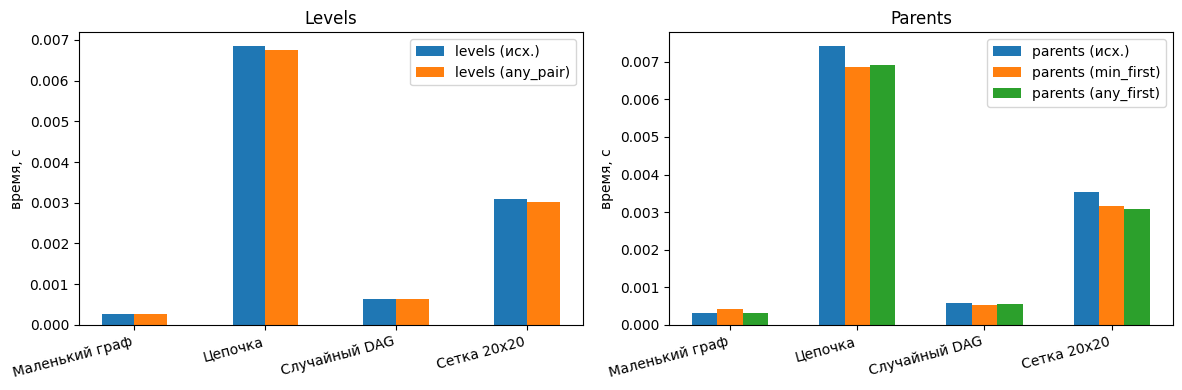

In [52]:
# Визуализация сравнения времени
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (title, cols) in zip(axes, [
    ("Levels", ["levels (исх.) с", "levels (any_pair) с"]),
    ("Parents", ["parents (исх.) с", "parents (min_first) с", "parents (any_first) с"]),
]):
    ax.set_title(title)
    x = np.arange(len(df))
    w = 0.25 if len(cols) == 2 else 0.2
    for i, c in enumerate(cols):
        ax.bar(x + i * w - (len(cols)-1)*w/2, df[c], width=w, label=c.replace(" с", ""))
    ax.set_xticks(x)
    ax.set_xticklabels(df["граф"], rotation=15, ha="right")
    ax.legend()
    ax.set_ylabel("время, с")
plt.tight_layout()
plt.show()

#### Вывод

Реализации на полукольцах `any_pair` и `any_first/min_first` дают те же результаты, что и исходные функции

Время может незначительно отличаться в зависимости от графа и устройства на котором запускается скрипт, но все равно остается близким к одинаковому